# Pandas - Calculos, Graficos y Lectura de Datos

> Visualizar datos es el primer paso del EDA (Analisis Exploratorio).
> Un buen grafico revela patrones, outliers y relaciones que los numeros solos no muestran.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Operaciones de Cálculo

In [45]:
diccionario = {
               'edades' : [30,25,25,24,30,20,25],
               'nota'   : [15,10,19,14,10,9,16]
              }
dataframe = pd.DataFrame(data = diccionario, index = ['A1','A2','A3','A4','A5','A6','A7'])
dataframe

,edades,nota
A1,30,15
A2,25,10
A3,25,19
A4,24,14
A5,30,10
A6,20,9
A7,25,16


### Conteos

In [4]:
#Valores únicos
dataframe['edades'].unique()

array([30, 25, 24, 20])

In [5]:
#Cantidad de valores únicos
dataframe['edades'].nunique()

4

In [6]:
#Conteo por edades
dataframe['edades'].value_counts()

,count
edades,
25,3
30,2
24,1
20,1


### Apply

In [12]:
#Aplicar una función sobre columnas
def porcentaje(x):
    return x/20;

In [8]:
#Aplicar una función sobre columnas (continuación...)
dataframe['nota'].apply(porcentaje)

,nota
A1,0.75
A2,0.50
A3,0.95
A4,0.70
A5,0.50
A6,0.45
A7,0.80


In [9]:
#Con función lambda
dataframe['nota'].apply(lambda x: x/20)

,nota
A1,0.75
A2,0.50
A3,0.95
A4,0.70
A5,0.50
A6,0.45
A7,0.80


---
### Tu turno: Apply y Lambda
Usando el dataframe de edades y notas:
1. Crea una columna "aprobado" que sea True si nota >= 11.
2. Crea una columna "categoria" con: "Excelente" si nota>=17, "Bueno" si >=14, "Regular" si >=11, "Desaprobado".
3. Cuenta cuantos hay en cada categoria

In [58]:
# Tu codigo aqui
dataframe['aprobado'] = dataframe['nota'] >= 11

def categorizar_nota(nota):
    if nota >= 17:
        return "Excelente"
    elif nota >= 14:
        return "Bueno"
    elif nota >= 11:
        return "Regular"
    else:
        return "Desaprobado"

dataframe['categoria'] = dataframe['nota'].apply(categorizar_nota)

conteo_categorias = dataframe['categoria'].value_counts()

print("Conteo por categoría:")
print(conteo_categorias)

Conteo por categoría:
categoria
Bueno          3
Desaprobado    3
Excelente      1
Name: count, dtype: int64


### Recuperar estructura

In [60]:
#Listado de las columnas de dataframe
cols = dataframe.columns
list(cols)

['edades', 'nota', 'aprobado', 'categoria']

In [62]:
#Listado de indices de dataframe
ind = dataframe.index
list(ind)

['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']

### Ordenamiento

In [64]:
dataframe.sort_values('edades')

,edades,nota,aprobado,categoria
A6,20,9,False,Desaprobado
A4,24,14,True,Bueno
A3,25,19,True,Excelente
A2,25,10,False,Desaprobado
A7,25,16,True,Bueno
A1,30,15,True,Bueno
A5,30,10,False,Desaprobado


In [54]:
dataframe.sort_values('edades', ascending=False)

,edades,nota,aprobado,categoria
A1,30,15,True,Bueno
A5,30,10,False,Desaprobado
A2,25,10,False,Desaprobado
A3,25,19,True,Excelente
A7,25,16,True,Bueno
A4,24,14,True,Bueno
A6,20,9,False,Desaprobado


In [55]:
dataframe.sort_index(ascending=False)

,edades,nota,aprobado,categoria
A7,25,16,True,Bueno
A6,20,9,False,Desaprobado
A5,30,10,False,Desaprobado
A4,24,14,True,Bueno
A3,25,19,True,Excelente
A2,25,10,False,Desaprobado
A1,30,15,True,Bueno


## Graficos

In [14]:
dataframe = pd.read_csv('/content/drive/MyDrive/LABS/00_DATASETS/Notas.csv', index_col='ANIO')
dataframe

,MATEMATICA,LENGUAJE,HISTORIA,INGLES
ANIO,,,,
2008,10,12,16,19
2009,12,8,6,4
2010,12,15,9,11
2011,12,15,10,7
2012,6,12,19,17
2013,10,13,14,13
2014,12,5,9,6


### histograma

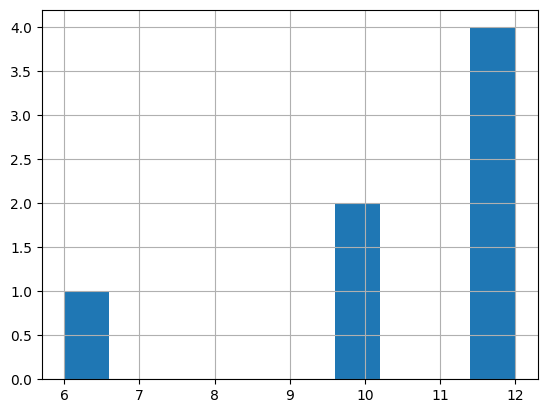

In [15]:
dataframe['MATEMATICA'].hist();

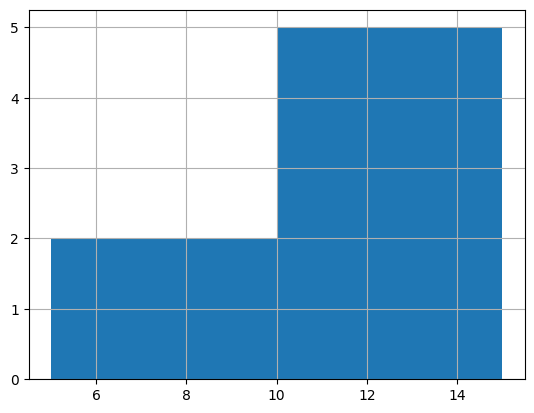

In [16]:
dataframe['LENGUAJE'].hist(bins = 2);

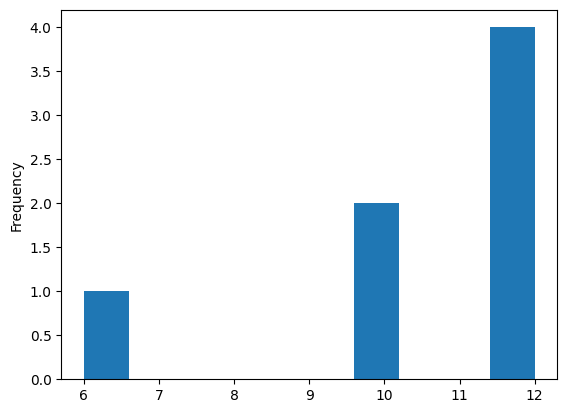

In [17]:
dataframe['MATEMATICA'].plot.hist();

### areas

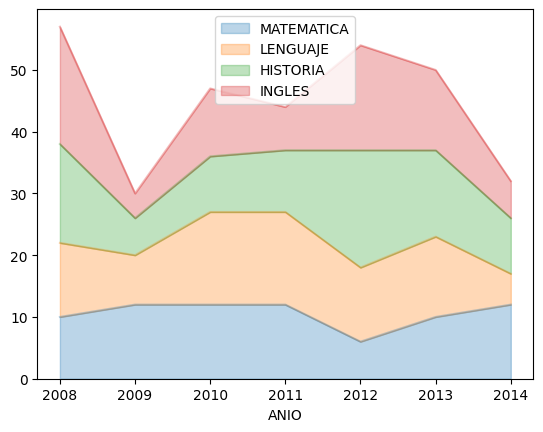

In [18]:
dataframe.plot.area(alpha = 0.3);

### barras

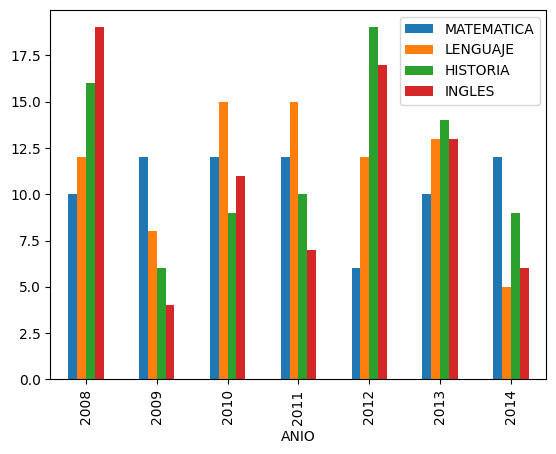

In [19]:
dataframe.plot.bar();

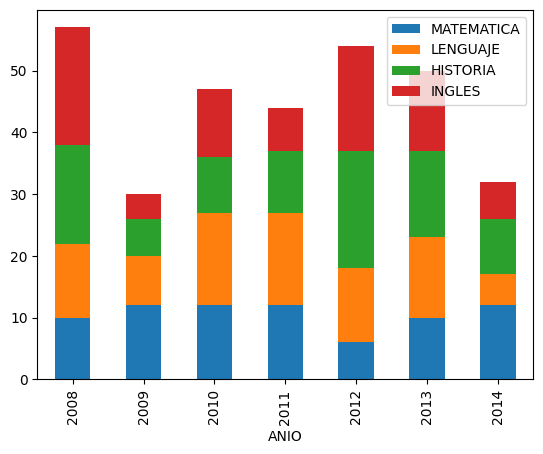

In [20]:
#Acumulados
dataframe.plot.bar(stacked=True);

### scatter

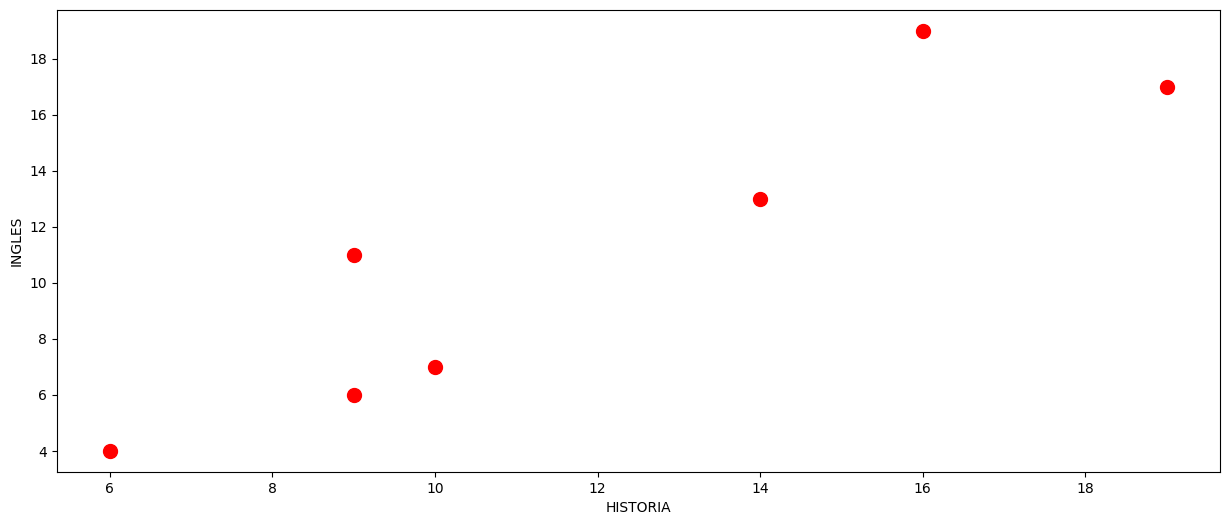

In [21]:
dataframe.plot.scatter(x = 'HISTORIA', y = 'INGLES', c='red',s = 100, figsize = (15,6));

### boxplot

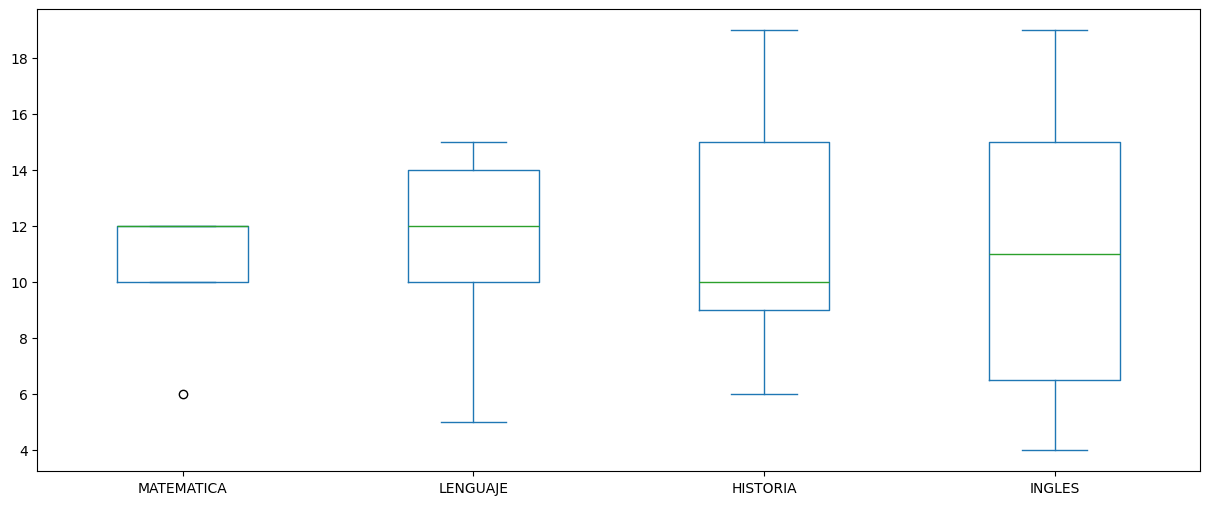

In [22]:
dataframe.plot.box(figsize = (15,6));

### densidad

In [67]:
#conda install scipy
import scipy

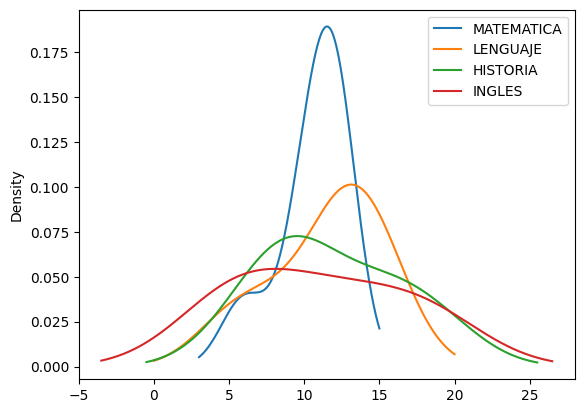

In [24]:
dataframe.plot.kde();

---
### Tu turno: Graficos
Usando el dataframe de Notas:
1. Histograma de MATEMATICA con 5 bins.
2. Grafico de barras comparando todas las materias.
3. Scatter: MATEMATICA vs INGLES

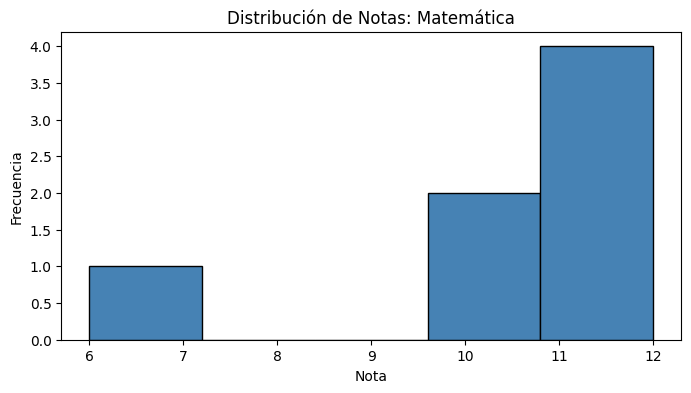

In [78]:
# Tu codigo aqui
dataframe = pd.read_csv('/content/drive/MyDrive/LABS/00_DATASETS/Notas.csv', index_col='ANIO')
dataframe

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dataframe['MATEMATICA'], bins=5, color="steelblue", edgecolor="black")
ax.set_title("Distribución de Notas: Matemática")
ax.set_xlabel("Nota")
ax.set_ylabel("Frecuencia")
plt.show()

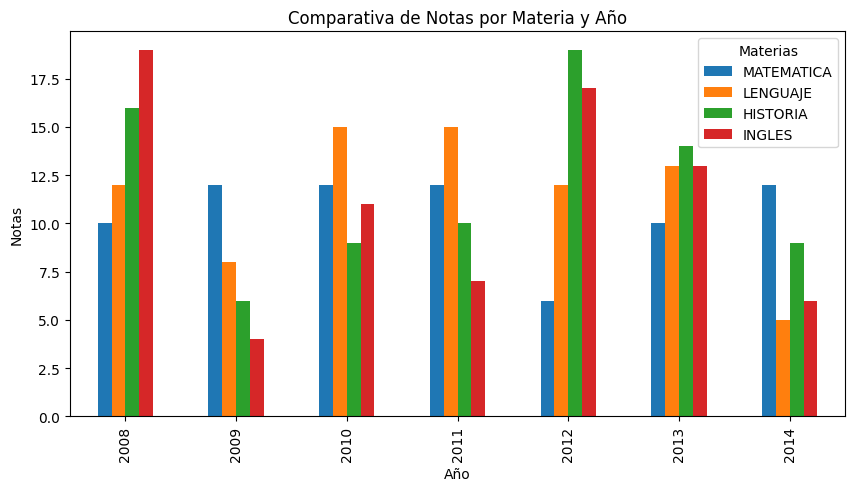

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))
dataframe.plot.bar(ax=ax)
ax.set_title("Comparativa de Notas por Materia y Año")
ax.set_xlabel("Año")
ax.set_ylabel("Notas")
ax.legend(title="Materias")
plt.show()

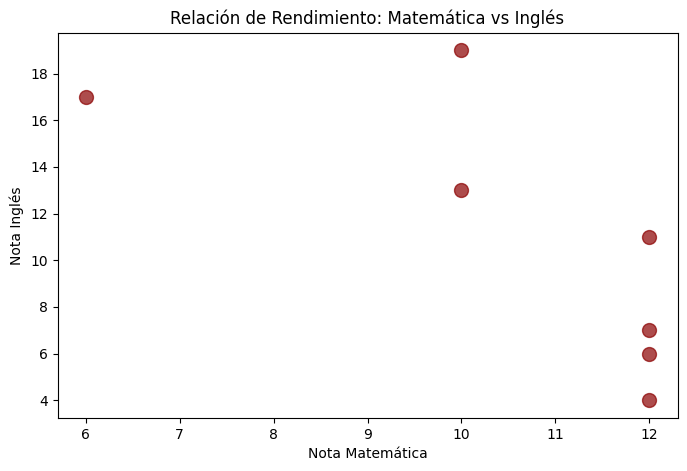

In [76]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dataframe['MATEMATICA'], dataframe['INGLES'], color="darkred", alpha=0.7, s=100)
ax.set_title("Relación de Rendimiento: Matemática vs Inglés")
ax.set_xlabel("Nota Matemática")
ax.set_ylabel("Nota Inglés")
plt.show()

---
## Lectura de Datos desde Archivos

> Los datos pueden venir de muchas fuentes.
> Pandas soporta: CSV, Excel, JSON, SQL, HTML, Parquet, y mas.

## Lectura de datos CSV

In [25]:
df = pd.read_csv("/content/drive/MyDrive/LABS/00_DATASETS/Carros_usados.csv")
df

,Car_Name,YYear,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
295,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
296,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
297,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
298,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


## Lectura de datos Excel

In [26]:
#Instalar : conda install -c anaconda openpyxl

In [27]:
df = pd.read_excel("/content/drive/MyDrive/LABS/00_DATASETS/Sismos.xlsx", sheet_name='3')
df.head(10)

,Departamento,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,Total,86,100,92,97,92,118,102,134,91,162,116,125,124,127,204,197,201,245
1,Amazonas,1,-,-,-,2,-,1,1,-,-,1,1,3,1,-,-,-,2
2,Áncash,-,1,1,1,-,-,2,-,-,-,-,-,1,1,1,1,3,2
3,Apurímac,1,-,1,3,1,3,1,4,1,1,4,1,1,2,2,4,-,1
4,Arequipa,15,14,14,16,24,11,23,16,10,13,12,14,15,15,16,52,26,99
5,Ayacucho,4,2,1,2,-,1,-,6,1,2,1,4,4,4,3,-,4,7
6,Cajamarca,2,-,-,-,1,-,2,2,1,5,-,3,2,-,-,3,7,1
7,Cusco,-,3,5,4,-,13,2,4,2,-,4,4,2,3,6,6,6,3
8,Huancavelica,1,3,1,-,1,4,1,9,7,5,3,1,3,3,-,2,5,2
9,Huánuco,1,7,-,1,-,2,-,-,4,6,1,3,2,3,5,6,2,6


## Lectura de datos html

In [28]:
#Instalar y reiniciar : pip install lxml

In [29]:
from lxml import html

In [33]:
url='https://es.wikipedia.org/wiki/Lionel_Messi'
df = pd.read_html(url)
df[14]

HTTPError: HTTP Error 403: Forbidden

## Limpiando los datos del Excel

In [34]:
df = pd.read_excel("/content/drive/MyDrive/LABS/00_DATASETS/Sismos.xlsx", sheet_name='3')

df.drop([0,15], axis = 0 , inplace=True)
df.dropna(how='all',inplace = True)
df.rename(columns=df.iloc[0], inplace = True)
df.drop([2,4], axis = 0, inplace=True)

df.reset_index(inplace = True)
df = df.drop(['index'], axis = 1)
df

,Amazonas,1,-,-,-,2,-,1,1,-,-,1,1,3,1,-,-,-,2
0,Amazonas,1,-,-,-,2,-,1,1,-,-,1,1,3,1,-,-,-,2
1,Apurímac,1,-,1,3,1,3,1,4,1,1,4,1,1,2,2,4,-,1
2,Ayacucho,4,2,1,2,-,1,-,6,1,2,1,4,4,4,3,-,4,7
3,Cajamarca,2,-,-,-,1,-,2,2,1,5,-,3,2,-,-,3,7,1
4,Cusco,-,3,5,4,-,13,2,4,2,-,4,4,2,3,6,6,6,3
5,Huancavelica,1,3,1,-,1,4,1,9,7,5,3,1,3,3,-,2,5,2
6,Huánuco,1,7,-,1,-,2,-,-,4,6,1,3,2,3,5,6,2,6
7,Ica,8,4,7,-,3,6,5,7,6,15,9,6,10,7,13,13,9,7
8,Junín,11,1,3,5,2,3,3,2,1,3,5,4,1,3,6,3,4,3
9,La Libertad,-,-,-,-,1,-,-,4,-,1,2,2,-,-,1,-,-,-


---
### Tu turno: Explorar un Dataset
Carga el dataset Carros_usados.csv y responde:
1. ¿Cuantas filas y columnas tiene?
2. Muestra las primeras 5 filas.
3. ¿Qué tipos de datos tiene cada columna?
4. ¿Hay nulos? ¿Cuantos por columna?
5. Estadisticos basicos de las columnas numericas.
6. ¿Cuantos autos hay por tipo de combustible?

In [89]:
# Tu codigo aqui
df_autos = pd.read_csv("/content/drive/MyDrive/LABS/00_DATASETS/Carros_usados.csv")

print(f"Forma del dataset (Filas, Columnas): {df_autos.shape}\n")

Forma del dataset (Filas, Columnas): (300, 9)



In [84]:
# 2. Muestra las primeras 5 filas
print("Primeras 5 filas:")
display(df_autos.head())

Primeras 5 filas:


,Car_Name,YYear,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [85]:
# 3. ¿Qué tipos de datos tiene cada columna?
print("\nTipos de datos por columna:")
print(df_autos.dtypes)


Tipos de datos por columna:
Car_Name          object
YYear              int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [86]:
# 4. ¿Hay nulos? ¿Cuántos por columna?
print("\nConteo de nulos por columna:")
print(df_autos.isnull().sum())


Conteo de nulos por columna:
Car_Name         0
YYear            0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [87]:
# 5. Estadísticos básicos de las columnas numéricas
print("\nEstadísticos descriptivos:")
display(df_autos.describe())


Estadísticos descriptivos:


,YYear,Selling_Price,Present_Price,Kms_Driven,Owner
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2013.663333,4.675667,7.646300,36647.030000,0.043333
std,2.830198,5.085175,8.653013,38600.967982,0.248317
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.625000,6.445000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48191.750000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [88]:
# 6. ¿Cuántos autos hay por tipo de combustible?
print("\nConteo por tipo de combustible:")
print(df_autos['Fuel_Type'].value_counts())


Conteo por tipo de combustible:
Fuel_Type
Petrol    238
Diesel     60
CNG         2
Name: count, dtype: int64


---
